# Assignment: Pandas Fundamentals with Earthquake Data

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 100)

##  Use Pandas’ read_csv function directly on this URL to open it as a DataFrame

In [4]:
url = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"
df = pd.read_csv(url)
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120108 entries, 0 to 120107
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       120108 non-null  object 
 1   latitude   120108 non-null  float64
 2   longitude  120108 non-null  float64
 3   depth      120107 non-null  float64
 4   mag        120065 non-null  float64
 5   magType    120065 non-null  object 
 6   nst        59688 non-null   float64
 7   gap        94935 non-null   float64
 8   dmin       85682 non-null   float64
 9   rms        119716 non-null  float64
 10  net        120108 non-null  object 
 11  id         120108 non-null  object 
 12  updated    120108 non-null  object 
 13  place      120108 non-null  object 
 14  type       120108 non-null  object 
dtypes: float64(8), object(7)
memory usage: 13.7+ MB


## Re-read the data in such a way that all date columns are identified as dates and the earthquake ID is used as the index

In [6]:
df = pd.read_csv(url, parse_dates=['time', 'updated'], index_col='id')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
ak11155107,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,2014-02-05 19:34:41.515000+00:00,"26km S of Redoubt Volcano, Alaska",earthquake
nn00436847,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,2014-02-01 01:35:09+00:00,"32km S of Alamo, Nevada",earthquake
ak11151142,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,2014-02-01 00:03:53.010000+00:00,"12km NNW of North Nenana, Alaska",earthquake
ak11151135,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,2014-01-31 23:41:25.007000+00:00,"22km S of Cantwell, Alaska",earthquake
ci37171541,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,2014-02-01 00:13:20.107000+00:00,"10km WNW of Progreso, Mexico",earthquake


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120108 entries, ak11155107 to ak11453389
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   time       120108 non-null  datetime64[ns]     
 1   latitude   120108 non-null  float64            
 2   longitude  120108 non-null  float64            
 3   depth      120107 non-null  float64            
 4   mag        120065 non-null  float64            
 5   magType    120065 non-null  object             
 6   nst        59688 non-null   float64            
 7   gap        94935 non-null   float64            
 8   dmin       85682 non-null   float64            
 9   rms        119716 non-null  float64            
 10  net        120108 non-null  object             
 11  updated    120108 non-null  datetime64[ns, UTC]
 12  place      120108 non-null  object             
 13  type       120108 non-null  object             
dtypes: datetime64[ns, UTC](1), d

## Use describe to get the basic statistics of all the columns

In [8]:
df.describe()

,time,latitude,longitude,depth,mag,nst,gap,dmin,rms
count,120108,120108.000000,120108.000000,120107.000000,120065.000000,59688.000000,94935.000000,85682.000000,119716.000000
mean,2014-07-05 09:10:37.116720128,38.399579,-99.961402,28.375029,1.793958,17.878284,124.048978,0.893198,0.358174
min,2014-01-01 00:01:16.610000,-73.462000,-179.998900,-9.900000,-0.970000,0.000000,9.000000,0.000000,0.000000
25%,2014-04-08 03:43:10.768999936,34.228917,-147.742025,4.100000,0.820000,8.000000,74.000000,0.020760,0.070000
50%,2014-07-07 10:44:06.035000064,38.805300,-120.832000,9.200000,1.400000,14.000000,107.000000,0.073670,0.200000
75%,2014-09-30 23:36:40.595000064,53.889500,-116.068100,22.880000,2.400000,22.000000,155.000000,0.447000,0.590000
max,2014-12-31 23:54:33.900000,86.651400,179.998000,697.360000,8.200000,365.000000,356.400000,64.498000,8.460000
std,NaN,21.938258,82.996858,62.215416,1.343466,14.911369,68.518595,2.903966,0.364046


In [9]:
df['mag'].min(), df['mag'].max()

(-0.97, 8.2)

## Use nlargest to get the top 20 earthquakes by magnitude

In [10]:
df.nlargest(20, 'mag')

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type
id,,,,,,,,,,,,,,
usc000nzvd,2014-04-01 23:46:47.260,-19.6097,-70.7691,25.00,8.2,mww,NaN,23.0,0.609,0.66,us,2015-07-30 16:24:51.223000+00:00,"94km NW of Iquique, Chile",earthquake
usc000rki5,2014-06-23 20:53:09.700,51.8486,178.7352,109.00,7.9,mww,NaN,22.0,0.133,0.71,us,2015-04-18 21:54:08.699000+00:00,"19km SE of Little Sitkin Island, Alaska",earthquake
usc000p27i,2014-04-03 02:43:13.110,-20.5709,-70.4931,22.40,7.7,mww,NaN,44.0,1.029,0.82,us,2015-06-06 07:31:05.755000+00:00,"53km SW of Iquique, Chile",earthquake
usc000phx5,2014-04-12 20:14:39.300,-11.2701,162.1481,22.56,7.6,mww,NaN,13.0,2.828,0.71,us,2015-04-18 21:54:27.398000+00:00,"93km SSE of Kirakira, Solomon Islands",earthquake
usb000pr89,2014-04-19 13:28:00.810,-6.7547,155.0241,43.37,7.5,mww,NaN,16.0,3.820,1.25,us,2015-04-18 21:54:18.633000+00:00,"70km SW of Panguna, Papua New Guinea",earthquake
usc000piqj,2014-04-13 12:36:19.230,-11.4633,162.0511,39.00,7.4,mww,NaN,17.0,2.885,1.00,us,2015-08-13 19:29:13.018000+00:00,"112km S of Kirakira, Solomon Islands",earthquake
usb000slwn,2014-10-14 03:51:34.460,12.5262,-88.1225,40.00,7.3,mww,NaN,18.0,1.078,0.70,us,2015-08-13 19:35:02.679000+00:00,"74km S of Intipuca, El Salvador",earthquake
usb000pq41,2014-04-18 14:27:24.920,17.3970,-100.9723,24.00,7.2,mww,NaN,46.0,2.250,1.20,us,2015-08-13 19:30:39.599000+00:00,"33km ESE of Petatlan, Mexico",earthquake
usc000pft9,2014-04-11 07:07:23.130,-6.5858,155.0485,60.53,7.1,mww,NaN,21.0,3.729,0.88,us,2014-07-01 02:37:56+00:00,"56km WSW of Panguna, Papua New Guinea",earthquake


In [11]:
df.nlargest(20, 'mag')[['mag', 'place', 'time']]

,mag,place,time
id,,,
usc000nzvd,8.2,"94km NW of Iquique, Chile",2014-04-01 23:46:47.260
usc000rki5,7.9,"19km SE of Little Sitkin Island, Alaska",2014-06-23 20:53:09.700
usc000p27i,7.7,"53km SW of Iquique, Chile",2014-04-03 02:43:13.110
usc000phx5,7.6,"93km SSE of Kirakira, Solomon Islands",2014-04-12 20:14:39.300
usb000pr89,7.5,"70km SW of Panguna, Papua New Guinea",2014-04-19 13:28:00.810
usc000piqj,7.4,"112km S of Kirakira, Solomon Islands",2014-04-13 12:36:19.230
usb000slwn,7.3,"74km S of Intipuca, El Salvador",2014-10-14 03:51:34.460
usb000pq41,7.2,"33km ESE of Petatlan, Mexico",2014-04-18 14:27:24.920
usc000pft9,7.1,"56km WSW of Panguna, Papua New Guinea",2014-04-11 07:07:23.130


In [12]:
df['place'].head(20)

id
ak11155107        26km S of Redoubt Volcano, Alaska
nn00436847                  32km S of Alamo, Nevada
ak11151142         12km NNW of North Nenana, Alaska
ak11151135               22km S of Cantwell, Alaska
ci37171541             10km WNW of Progreso, Mexico
ci11419722                 3km N of Tijuana, Mexico
ci11419714    11km N of Borrego Springs, California
ak11151127            61km NNW of Talkeetna, Alaska
ak11151125               48km NNE of Kodiak, Alaska
nc72153361           3km E of Livermore, California
usc000mqlp     115km ESE of Taron, Papua New Guinea
ak11155101              71km SE of Whittier, Alaska
nc72153351         0km N of The Geysers, California
nc72153356     4km WSW of Mammoth Lakes, California
usc000mqln     120km N of Raoul Island, New Zealand
nm020414a             6km SSW of Lilbourn, Missouri
usc000mqls                South of the Fiji Islands
ci11419698           27km ESE of Julian, California
ci11419706          52km S of Lone Pine, California
ak1115110

In [13]:
df['state_country'] = df['place'].str.split(',').str[-1].str.strip()
df[['place', 'state_country']].head(20)

,place,state_country
id,,
ak11155107,"26km S of Redoubt Volcano, Alaska",Alaska
nn00436847,"32km S of Alamo, Nevada",Nevada
ak11151142,"12km NNW of North Nenana, Alaska",Alaska
ak11151135,"22km S of Cantwell, Alaska",Alaska
ci37171541,"10km WNW of Progreso, Mexico",Mexico
ci11419722,"3km N of Tijuana, Mexico",Mexico
ci11419714,"11km N of Borrego Springs, California",California
ak11151127,"61km NNW of Talkeetna, Alaska",Alaska
ak11151125,"48km NNE of Kodiak, Alaska",Alaska


## Extract the state or country using Pandas text data functions

In [14]:
df['country'] = df['place'].str.split(',').str[-1].str.strip()
df[['place', 'country']].head(20)

,place,country
id,,
ak11155107,"26km S of Redoubt Volcano, Alaska",Alaska
nn00436847,"32km S of Alamo, Nevada",Nevada
ak11151142,"12km NNW of North Nenana, Alaska",Alaska
ak11151135,"22km S of Cantwell, Alaska",Alaska
ci37171541,"10km WNW of Progreso, Mexico",Mexico
ci11419722,"3km N of Tijuana, Mexico",Mexico
ci11419714,"11km N of Borrego Springs, California",California
ak11151127,"61km NNW of Talkeetna, Alaska",Alaska
ak11151125,"48km NNE of Kodiak, Alaska",Alaska


## Display each unique value from the new column

In [15]:
df['country'].unique()

array(['Alaska', 'Nevada', 'Mexico', 'California', 'Papua New Guinea',
       'New Zealand', 'Missouri', 'South of the Fiji Islands', 'Montana',
       'British Virgin Islands', 'Washington', 'Oregon', 'Canada', 'Fiji',
       'Wyoming', 'Antarctica', 'Chile', 'Utah', 'Indonesia',
       'Solomon Islands', 'Micronesia', 'Oklahoma', 'Hawaii', 'Russia',
       'Arizona', 'Philippines', 'Bolivia', 'Greece', 'Japan',
       'Puerto Rico', 'Iran', 'Tonga', 'Wallis and Futuna', 'Colorado',
       'Guam', 'CA', 'Carlsberg Ridge', 'Idaho', 'Pakistan',
       'Off the west coast of northern Sumatra', 'Burma', 'China', 'Peru',
       'Off the east coast of the North Island of New Zealand',
       'Costa Rica', 'Reykjanes Ridge', 'East Timor',
       'Central East Pacific Rise', 'Mid-Indian Ridge', 'Japan region',
       'Northern Mariana Islands', 'El Salvador', 'Samoa',
       'Northern Mid-Atlantic Ridge', 'Taiwan', 'Arkansas',
       'South Sandwich Islands', 'Colombia', 'Dominican Republic',

## Create a filtered dataset that only has earthquakes of magnitude 4 or larger and

In [16]:
df_mag4 = df[df['mag'] >= 4]
df_mag4.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,updated,place,type,state_country,country
id,,,,,,,,,,,,,,,,
usc000mqlp,2014-01-31 23:08:03.660,-4.9758,153.9466,110.18,4.2,mb,NaN,98.0,1.940,0.61,us,2014-04-08 01:43:19+00:00,"115km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea,Papua New Guinea
usc000mqln,2014-01-31 22:54:32.970,-28.1775,-177.9058,95.84,4.3,mb,NaN,104.0,1.063,1.14,us,2014-04-08 01:43:19+00:00,"120km N of Raoul Island, New Zealand",earthquake,New Zealand,New Zealand
usc000mqls,2014-01-31 22:49:49.740,-23.1192,179.1174,528.34,4.4,mb,NaN,80.0,5.439,0.95,us,2014-04-08 01:43:19+00:00,South of the Fiji Islands,earthquake,South of the Fiji Islands,South of the Fiji Islands
usc000mf1x,2014-01-31 22:19:44.330,51.1569,-178.0910,37.50,4.2,mb,NaN,NaN,NaN,0.83,us,2014-04-08 01:43:19+00:00,"72km E of Amatignak Island, Alaska",earthquake,Alaska,Alaska
usc000mqlm,2014-01-31 21:56:44.320,-4.8800,153.8434,112.66,4.3,mb,NaN,199.0,1.808,0.79,us,2014-04-08 01:43:19+00:00,"100km ESE of Taron, Papua New Guinea",earthquake,Papua New Guinea,Papua New Guinea


## Using the filtered dataset (magnitude > 4), count the number of earthquakes in each country/state. Make a bar chart of this number for the top 5 locations with the most earthquakes

In [17]:
counts = df_mag4['country'].value_counts()
counts.head(5)

country
Indonesia           2116
Papua New Guinea    1354
Japan               1150
Chile               1124
New Zealand          758
Name: count, dtype: int64

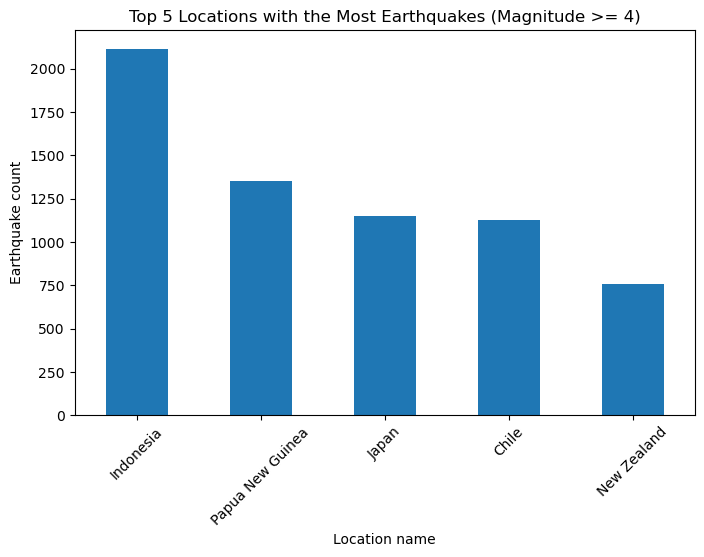

In [18]:
counts.head(5).plot(kind='bar', figsize=(8,5))
plt.xlabel('Location name')
plt.ylabel('Earthquake count')
plt.title('Top 5 Locations with the Most Earthquakes (Magnitude >= 4)')
plt.xticks(rotation=45)
plt.show()

## Make a histogram the distribution of the Earthquake magnitudes

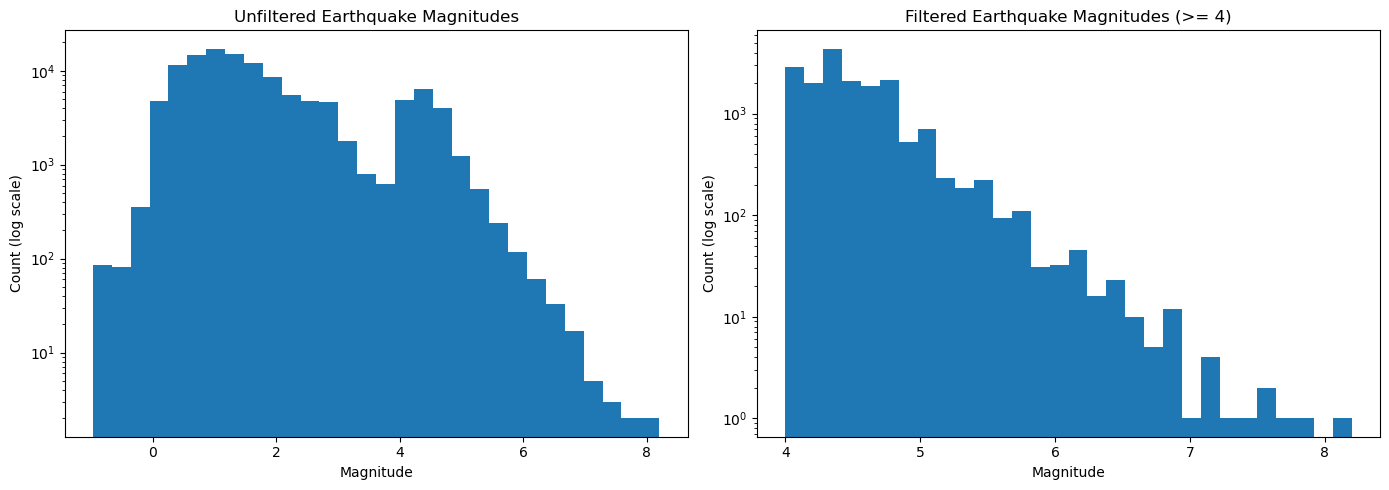

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['mag'].hist(ax=ax[0], bins=30, log=True)
ax[0].set_title('Unfiltered Earthquake Magnitudes')
ax[0].set_xlabel('Magnitude')
ax[0].set_ylabel('Count (log scale)')
ax[0].grid(False)

df_mag4['mag'].hist(ax=ax[1], bins=30, log=True)
ax[1].set_title('Filtered Earthquake Magnitudes (>= 4)')
ax[1].set_xlabel('Magnitude')
ax[1].set_ylabel('Count (log scale)')
ax[1].grid(False)

plt.tight_layout()
plt.show()

#### There is a clear negative relationship between earthquake magnitude and frequency. Low-magnitude earthquakes happen much more often than high-magnitude earthquakes. On the log scale, the filtered histogram shows a roughly linear downward trend.

## Visualize the locations of earthquakes by making a scatterplot of their latitude and longitude

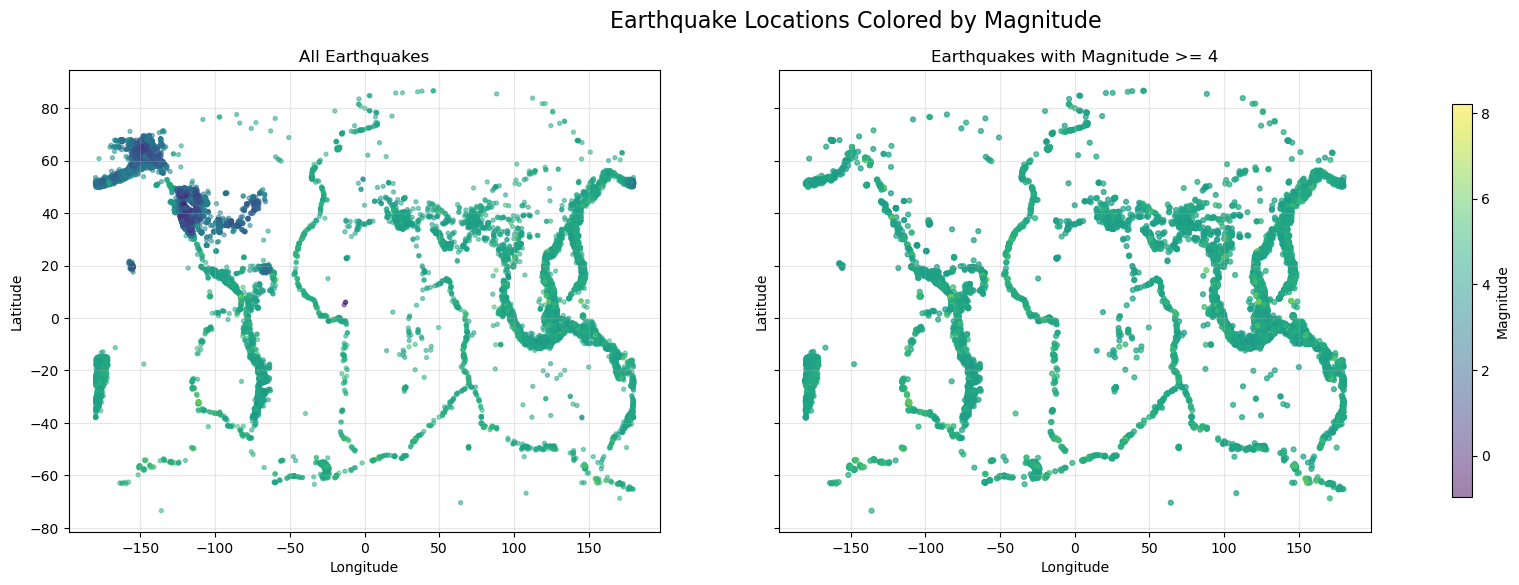

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(21, 6), sharex=True, sharey=True)

vmin = df['mag'].min()
vmax = df['mag'].max()

sc1 = ax[0].scatter(
    df['longitude'], df['latitude'],
    c=df['mag'], s=8, alpha=0.5, cmap='viridis',
    vmin=vmin, vmax=vmax
)

ax[0].set_title('All Earthquakes')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')
ax[0].grid(True, alpha=0.3)

sc2 = ax[1].scatter(
    df_mag4['longitude'], df_mag4['latitude'],
    c=df_mag4['mag'], s=12, alpha=0.7, cmap='viridis',
    vmin=vmin, vmax=vmax
)

ax[1].set_title('Earthquakes with Magnitude >= 4')
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')
ax[1].grid(True, alpha=0.3)

cbar = fig.colorbar(sc1, ax=ax, shrink=0.85)
cbar.set_label('Magnitude')

plt.suptitle('Earthquake Locations Colored by Magnitude', fontsize=16)
plt.show()

#### The unfiltered dataset is much denser and more crowded because it includes many smaller earthquakes. The filtered dataset has fewer points, so the major earthquake belts and larger events stand out more clearly. 